In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("Cleaned_Dataset.xls")

# -----------------------------
# Data Cleaning
# -----------------------------
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")
df["Date"] = pd.to_datetime(df["Date"])

# -----------------------------
# Basic Information
# -----------------------------
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\nDataset Information")
print("="*60)
print(df.info())


Dataset Shape
(1200, 14)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       

In [42]:
# -----------------------------
# Descriptive Statistics
# -----------------------------
print("\nDescriptive Statistics")
print("="*60)
print(df.describe())

# Mean, Median, Count
print("\nMean")
print(df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].mean())

print("\nMedian")
print(df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].median())

print("\nCount")
print(df.count())


Descriptive Statistics
                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558

Mean
Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64

Median
Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

Count
OrderID       

In [43]:
# -----------------------------
# Value Counts
# -----------------------------
print("\nOrder Status Distribution")
print(df["OrderStatus"].value_counts())

print("\nPayment Method Distribution")
print(df["PaymentMethod"].value_counts())

print("\nReferral Source Distribution")
print(df["ReferralSource"].value_counts())


Order Status Distribution
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Payment Method Distribution
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

Referral Source Distribution
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


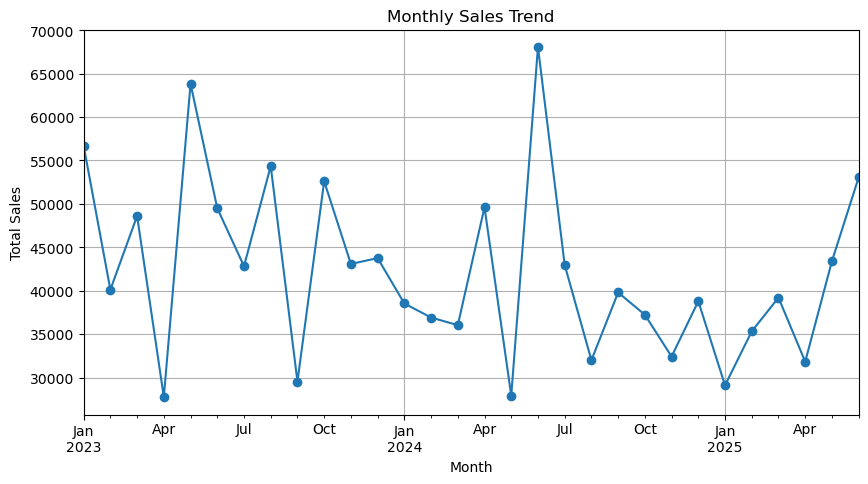

In [44]:
# -----------------------------
# Monthly Sales Trend
# -----------------------------
df["Month"] = df["Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

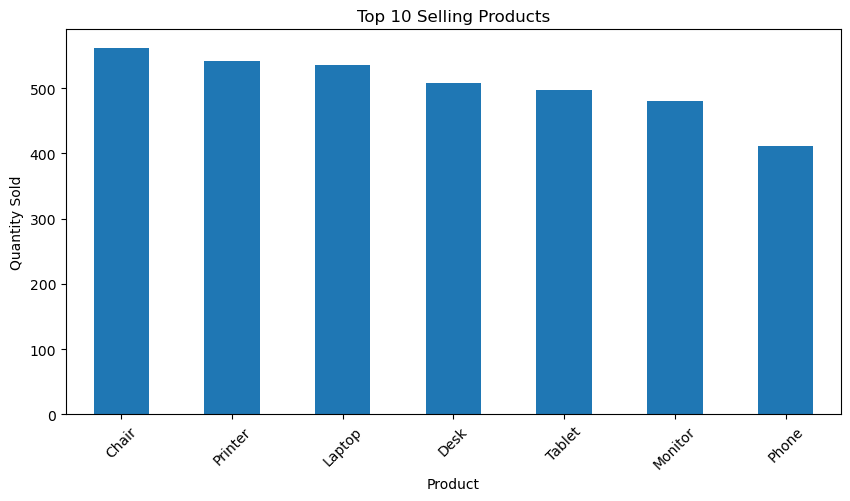

In [45]:
# -----------------------------
# Top 10 Products
# -----------------------------
top_products = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

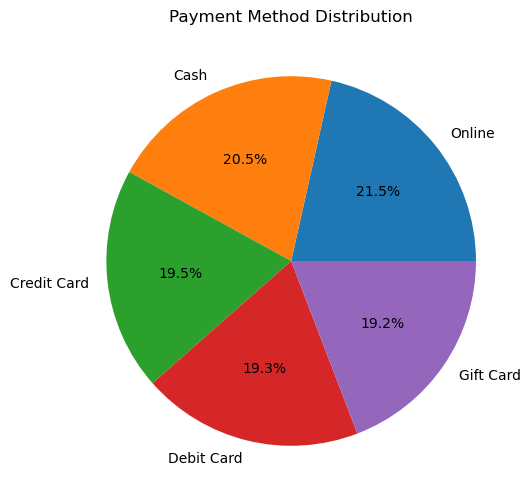

In [46]:
# -----------------------------
# Payment Methods
# -----------------------------
payment_counts = df["PaymentMethod"].value_counts()

plt.figure(figsize=(6,6))
payment_counts.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Payment Method Distribution")
plt.show()

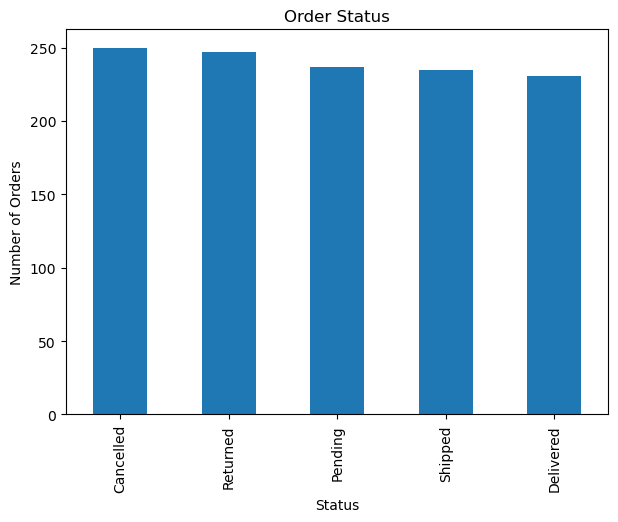

In [47]:
# -----------------------------
# Order Status
# -----------------------------
plt.figure(figsize=(7,5))
df["OrderStatus"].value_counts().plot(kind="bar")
plt.title("Order Status")
plt.xlabel("Status")
plt.ylabel("Number of Orders")
plt.show()

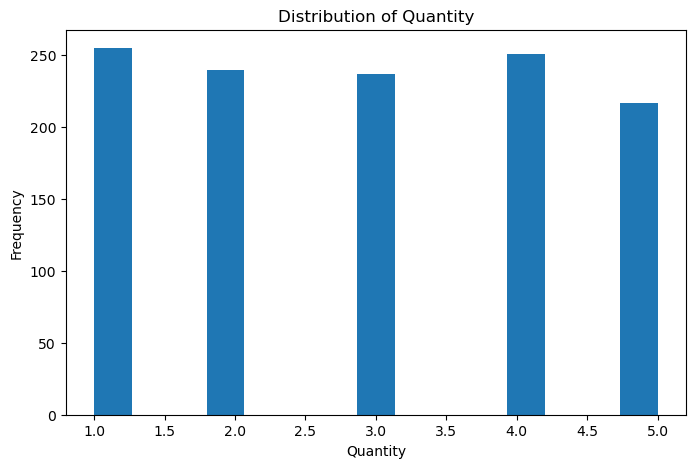

In [48]:
# -----------------------------
# Quantity Distribution
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=15)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

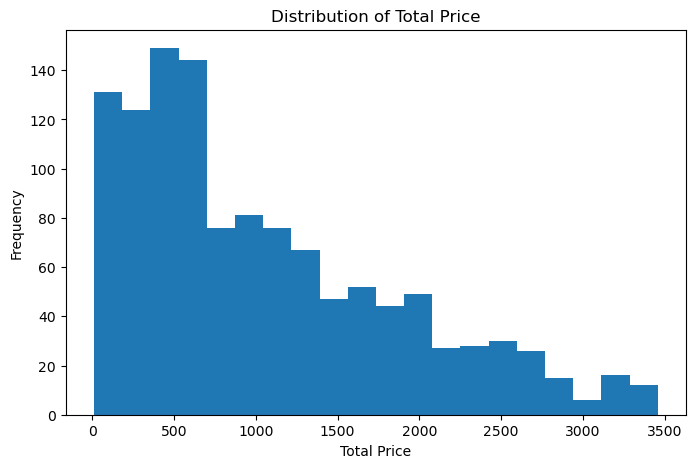

In [49]:
# -----------------------------
# Total Price Distribution
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df["TotalPrice"], bins=20)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

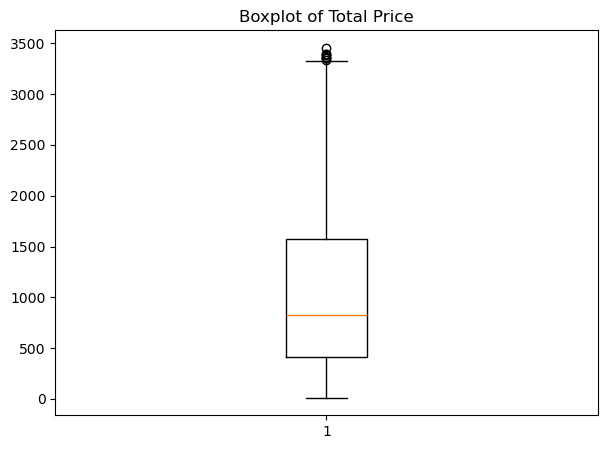


Number of Outliers: 8


In [50]:
# -----------------------------
# Outlier Detection
# -----------------------------
plt.figure(figsize=(7,5))
plt.boxplot(df["TotalPrice"])
plt.title("Boxplot of Total Price")
plt.show()

Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df["TotalPrice"] < lower) | (df["TotalPrice"] > upper)]

print("\nNumber of Outliers:", len(outliers))


Correlation Matrix
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


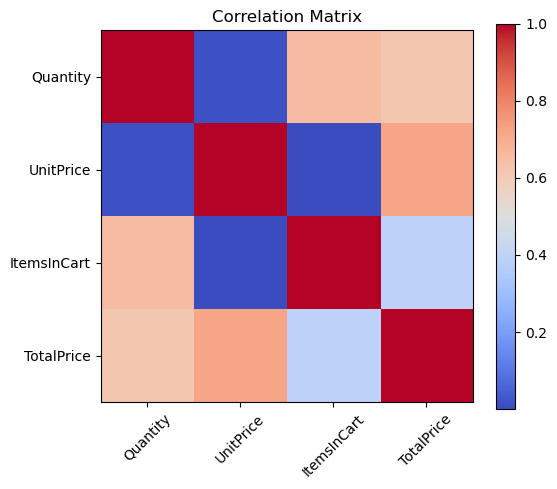

In [51]:
# -----------------------------
# Correlation
# -----------------------------
corr = df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].corr()

print("\nCorrelation Matrix")
print(corr)

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()